# EURUSD H4 Momentum Capture Module Improvement

This notebook builds an interpretable research pipeline for predicting volatility-scaled forward returns on EURUSD H4 bars.

**Scope**

- Download 5-7 years of EURUSD H4 OHLC data from MetaTrader 5.
- Create economically meaningful momentum, trend, volatility, and regime-aware feature groups.
- Predict vol-scaled forward returns over 1, 3, and 6 H4 bars.
- Compare shallow tree-based regressors: Decision Tree, Random Forest, and XGBoost.
- Evaluate with walk-forward folds, purging, prediction quality metrics, and a simple trading proxy.
- Inspect model behavior using feature importance, shallow tree structure, partial dependence, and linear approximation.

**Trading research warnings**

- Avoid look-ahead bias: features use information available at time `t`; targets use future returns only for labels.
- Backtest metrics below are research diagnostics, not a production execution simulation.
- Transaction costs, spread, slippage, roll, liquidity, MT5 server timezone, and data quality can dominate H4 edge estimates.
- Shallow models are intentionally used to preserve interpretability.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from typing import Callable, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

from sklearn.base import clone
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import MetaTrader5 as mt5
except ImportError as exc:
    mt5 = None
    warnings.warn("MetaTrader5 package is not installed. Install it in the active Python environment to download data.")

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
    warnings.warn("xgboost package is not installed. XGBRegressor runs will be skipped.")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
SYMBOL = "EURUSD"
TIMEFRAME = "H4"
YEARS_BACK = 7
HORIZONS = [1, 3, 6]
MAX_TREE_DEPTH = 3
TRANSACTION_COST_BPS = 0.2  # One-way cost assumption for simple strategy diagnostics.

plt.style.use("seaborn-v0_8-whitegrid")

## 2. MT5 Connection and Data Download

The code below expects the MetaTrader 5 desktop terminal to be installed, configured, and logged in. Different brokers may expose suffixes such as `EURUSD.a` or `EURUSDm`; adjust `SYMBOL` if needed.

In [2]:
def initialize_mt5() -> None:
    """Initialize MT5 and raise a clear error if the terminal is unavailable."""
    if mt5 is None:
        raise ImportError("MetaTrader5 is not installed. Run: pip install MetaTrader5")
    if not mt5.initialize():
        code, message = mt5.last_error()
        raise RuntimeError(f"MT5 initialization failed: {code} - {message}")


def mt5_timeframe(name: str):
    mapping = {
        "M1": mt5.TIMEFRAME_M1,
        "M5": mt5.TIMEFRAME_M5,
        "M15": mt5.TIMEFRAME_M15,
        "M30": mt5.TIMEFRAME_M30,
        "H1": mt5.TIMEFRAME_H1,
        "H4": mt5.TIMEFRAME_H4,
        "D1": mt5.TIMEFRAME_D1,
    }
    return mapping[name.upper()]


def download_mt5_ohlc(symbol: str = SYMBOL, timeframe: str = TIMEFRAME, years_back: int = YEARS_BACK) -> pd.DataFrame:
    """Download OHLCV bars from MT5 and return a cleaned, UTC-indexed DataFrame."""
    initialize_mt5()
    tf = mt5_timeframe(timeframe)

    end_utc = datetime.now(timezone.utc)
    start_utc = end_utc - timedelta(days=int(365.25 * years_back))

    info = mt5.symbol_info(symbol)
    if info is None:
        available = [s.name for s in mt5.symbols_get("*EUR*USD*") or []][:20]
        raise ValueError(f"Symbol {symbol!r} not found. Similar symbols: {available}")
    if not info.visible:
        if not mt5.symbol_select(symbol, True):
            raise RuntimeError(f"Could not select {symbol!r} in Market Watch.")

    rates = mt5.copy_rates_range(symbol, tf, start_utc, end_utc)
    if rates is None or len(rates) == 0:
        code, message = mt5.last_error()
        raise RuntimeError(f"No rates returned for {symbol} {timeframe}: {code} - {message}")

    df = pd.DataFrame(rates)
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("time").sort_index()
    df = df.rename(columns={"open": "Open", "high": "High", "low": "Low", "close": "Close", "tick_volume": "TickVolume"})
    keep = ["Open", "High", "Low", "Close", "TickVolume", "spread", "real_volume"]
    df = df[[c for c in keep if c in df.columns]]
    df = df[~df.index.duplicated(keep="last")]
    df = df.dropna(subset=["Open", "High", "Low", "Close"])
    return df


# Run this cell when MT5 is available. If you already have a DataFrame named raw, skip or replace this line.
raw = download_mt5_ohlc(SYMBOL, TIMEFRAME, YEARS_BACK)
print(raw.shape)
display(raw.head())
display(raw.tail())

# Keep terminal connection clean after download.
if mt5 is not None:
    mt5.shutdown()

(10880, 7)


,Open,High,Low,Close,TickVolume,spread,real_volume
time,,,,,,,
2019-05-07 20:00:00+00:00,1.11743,1.11930,1.11699,1.11906,8316,8,0
2019-05-08 00:00:00+00:00,1.11914,1.11943,1.11874,1.11921,3352,4,0
2019-05-08 04:00:00+00:00,1.11921,1.12063,1.11921,1.12048,6256,8,0
2019-05-08 08:00:00+00:00,1.12048,1.12123,1.11961,1.11977,12505,8,0
2019-05-08 12:00:00+00:00,1.11977,1.12072,1.11888,1.11982,17038,8,0


,Open,High,Low,Close,TickVolume,spread,real_volume
time,,,,,,,
2026-05-06 00:00:00+00:00,1.16902,1.17249,1.16871,1.17196,5306,11,0
2026-05-06 04:00:00+00:00,1.17193,1.17422,1.17150,1.17364,7679,11,0
2026-05-06 08:00:00+00:00,1.17363,1.17699,1.17237,1.17622,9540,11,0
2026-05-06 12:00:00+00:00,1.17615,1.17962,1.17511,1.17529,12973,11,0
2026-05-06 16:00:00+00:00,1.17525,1.17624,1.17413,1.17437,11659,11,0


## 3. Data Quality Checks

,start,end,rows,missing_ohlc,median_gap,max_gap
0,2019-05-07 20:00:00+00:00,2026-05-06 16:00:00+00:00,10880,0,0 days 04:00:00,4 days 04:00:00


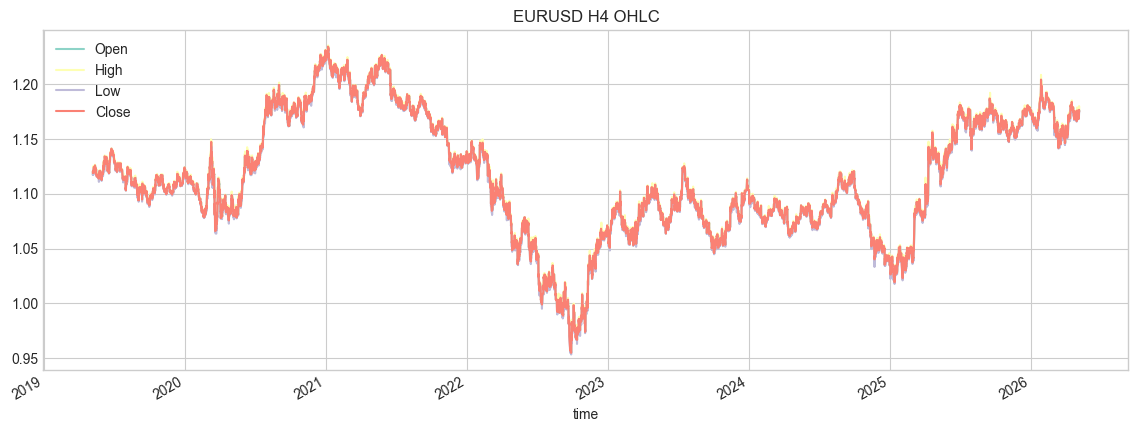

In [3]:
def summarize_ohlc(df: pd.DataFrame) -> pd.DataFrame:
    gaps = df.index.to_series().diff().dropna()
    summary = pd.DataFrame({
        "start": [df.index.min()],
        "end": [df.index.max()],
        "rows": [len(df)],
        "missing_ohlc": [int(df[["Open", "High", "Low", "Close"]].isna().sum().sum())],
        "median_gap": [gaps.median() if not gaps.empty else pd.NaT],
        "max_gap": [gaps.max() if not gaps.empty else pd.NaT],
    })
    return summary


display(summarize_ohlc(raw))
raw[["Open", "High", "Low", "Close"]].plot(figsize=(14, 5), title=f"{SYMBOL} {TIMEFRAME} OHLC")
plt.show()

## 4. Feature Engineering

Features are grouped by economic interpretation. All feature calculations below use current and historical information only.

In [4]:
def rolling_slope(values: pd.Series, window: int) -> pd.Series:
    """OLS slope of values over a rolling window, scaled per bar."""
    x = np.arange(window, dtype=float)
    x = x - x.mean()
    denom = np.sum(x ** 2)

    def _slope(y: np.ndarray) -> float:
        if np.any(~np.isfinite(y)):
            return np.nan
        return float(np.dot(x, y - y.mean()) / denom)

    return values.rolling(window).apply(_slope, raw=True)


def rolling_slope_r2(values: pd.Series, window: int) -> Tuple[pd.Series, pd.Series]:
    """Rolling OLS slope and R-squared."""
    x = np.arange(window, dtype=float)
    x_centered = x - x.mean()
    denom = np.sum(x_centered ** 2)

    def _slope(y: np.ndarray) -> float:
        if np.any(~np.isfinite(y)):
            return np.nan
        return float(np.dot(x_centered, y - y.mean()) / denom)

    def _r2(y: np.ndarray) -> float:
        if np.any(~np.isfinite(y)):
            return np.nan
        slope = np.dot(x_centered, y - y.mean()) / denom
        intercept = y.mean() - slope * x.mean()
        y_hat = intercept + slope * x
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

    return values.rolling(window).apply(_slope, raw=True), values.rolling(window).apply(_r2, raw=True)


def add_atr_adx(df: pd.DataFrame, period: int = 14) -> pd.DataFrame:
    """Add ATR, ADX, +DI, and -DI using Wilder-style exponential smoothing."""
    out = df.copy()
    high, low, close = out["High"], out["Low"], out["Close"]
    prev_close = close.shift(1)

    tr = pd.concat([(high - low), (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=out.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=out.index)

    atr = tr.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    plus_di = 100 * plus_dm.ewm(alpha=1 / period, adjust=False, min_periods=period).mean() / atr
    minus_di = 100 * minus_dm.ewm(alpha=1 / period, adjust=False, min_periods=period).mean() / atr
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    adx = dx.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()

    out[f"ATR_{period}"] = atr
    out[f"plus_DI_{period}"] = plus_di
    out[f"minus_DI_{period}"] = minus_di
    out[f"ADX_{period}"] = adx
    return out


def make_features(df: pd.DataFrame) -> pd.DataFrame:
    out = add_atr_adx(df, period=14)
    close = out["Close"]
    ret = close.pct_change()
    log_close = np.log(close)

    # Group 1: Pure short-term momentum.
    out["ret_1"] = ret
    for lag in [2, 3, 5, 10]:
        out[f"ret_{lag}"] = close.pct_change(lag)
    for span in [5, 10, 20]:
        out[f"ewma_ret_{span}"] = ret.ewm(span=span, adjust=False, min_periods=span).mean()
    out["momentum_slope_10"] = rolling_slope(log_close, 10)
    out["momentum_slope_20"] = rolling_slope(log_close, 20)

    # Group 2: Multi-horizon momentum and trend strength.
    out["SMA_10"] = close.rolling(10).mean()
    out["SMA_20"] = close.rolling(20).mean()
    out["SMA_10_20_ratio"] = out["SMA_10"] / out["SMA_20"] - 1.0
    out["price_to_SMA_10"] = close / out["SMA_10"] - 1.0
    out["price_to_SMA_20"] = close / out["SMA_20"] - 1.0
    out["trend_slope_20"], out["trend_r2_20"] = rolling_slope_r2(log_close, 20)
    out["trend_slope_40"], out["trend_r2_40"] = rolling_slope_r2(log_close, 40)

    # Group 3: Volatility-adjusted momentum.
    out["vol_20"] = ret.rolling(20).std()
    out["vol_60"] = ret.rolling(60).std()
    out["vol_ratio_20_60"] = out["vol_20"] / out["vol_60"]
    inv_vol_20 = 1.0 / out["vol_20"].replace(0, np.nan)
    inv_atr_14 = 1.0 / out["ATR_14"].replace(0, np.nan)
    out["mom10_inv_vol20"] = out["ret_10"] * inv_vol_20
    out["trend20_x_ADX"] = out["trend_slope_20"] * out["ADX_14"]
    out["ret1_x_vol_ratio"] = out["ret_1"] * out["vol_ratio_20_60"]
    out["ewma10_inv_ATR14"] = out["ewma_ret_10"] * inv_atr_14

    # Group 4: Regime-aware interactions.
    vol_threshold = out["vol_20"].rolling(252, min_periods=100).quantile(0.70)
    out["high_vol_dummy"] = (out["vol_20"] > vol_threshold).astype(float)
    out["strong_trend_dummy"] = (out["ADX_14"] > 25).astype(float)
    out["momentum_signal"] = out["ewma_ret_10"]
    out["momentum_x_high_vol"] = out["momentum_signal"] * out["high_vol_dummy"]
    out["momentum_x_strong_trend"] = out["momentum_signal"] * out["strong_trend_dummy"]
    out["momentum_5_x_20"] = out["ret_5"] * out["ret_10"]

    return out


features = make_features(raw)
display(features.tail())

,Open,High,Low,Close,TickVolume,spread,real_volume,ATR_14,plus_DI_14,minus_DI_14,ADX_14,ret_1,ret_2,ret_3,ret_5,ret_10,ewma_ret_5,ewma_ret_10,ewma_ret_20,momentum_slope_10,momentum_slope_20,SMA_10,SMA_20,SMA_10_20_ratio,price_to_SMA_10,price_to_SMA_20,trend_slope_20,trend_r2_20,trend_slope_40,trend_r2_40,vol_20,vol_60,vol_ratio_20_60,mom10_inv_vol20,trend20_x_ADX,ret1_x_vol_ratio,ewma10_inv_ATR14,high_vol_dummy,strong_trend_dummy,momentum_signal,momentum_x_high_vol,momentum_x_strong_trend,momentum_5_x_20
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-06 00:00:00+00:00,1.16902,1.17249,1.16871,1.17196,5306,11,0,0.002733,24.779170,18.211728,16.584226,0.002901,0.003571,0.003253,0.000102,-0.003181,0.000748,0.000254,0.000094,-0.000389,0.000045,1.170982,1.171075,-0.000079,0.000835,0.000756,0.000045,0.013862,-0.000021,0.017539,0.001474,0.001142,1.290850,-2.158082,0.000744,0.003745,0.093086,0.0,0.0,0.000254,0.0,0.0,-3.257527e-07
2026-05-06 04:00:00+00:00,1.17193,1.17422,1.17150,1.17364,7679,11,0,0.002732,27.540482,16.916433,17.106596,0.001433,0.004339,0.005009,0.002374,-0.000094,0.000977,0.000469,0.000221,-0.000108,0.000033,1.170971,1.171364,-0.000335,0.002279,0.001943,0.000033,0.007778,-0.000011,0.004508,0.001500,0.001154,1.300276,-0.062476,0.000563,0.001864,0.171600,0.0,0.0,0.000469,0.0,0.0,-2.225138e-07
2026-05-06 08:00:00+00:00,1.17363,1.17699,1.17237,1.17622,9540,11,0,0.002867,31.272307,14.968977,18.403060,0.002198,0.003635,0.006546,0.006900,0.004115,0.001384,0.000783,0.000409,0.000160,0.000019,1.171453,1.171877,-0.000362,0.004069,0.003706,0.000019,0.002827,0.000006,0.001353,0.001491,0.001187,1.255793,2.759603,0.000349,0.002761,0.273227,0.0,0.0,0.000783,0.0,0.0,2.839060e-05
2026-05-06 12:00:00+00:00,1.17615,1.17962,1.17511,1.17529,12973,11,0,0.002984,34.191818,13.352928,20.219274,-0.000791,0.001406,0.002841,0.006422,0.002260,0.000659,0.000497,0.000295,0.000407,0.000007,1.171718,1.172247,-0.000451,0.003049,0.002596,0.000007,0.000382,0.000020,0.012027,0.001486,0.001175,1.264591,1.520768,0.000136,-0.001000,0.166577,0.0,0.0,0.000497,0.0,0.0,1.451368e-05
2026-05-06 16:00:00+00:00,1.17525,1.17624,1.17413,1.17437,11659,11,0,0.002921,32.427925,15.060112,21.387399,-0.000783,-0.001573,0.000622,0.004963,0.001296,0.000178,0.000264,0.000192,0.000595,-0.000008,1.171870,1.172505,-0.000542,0.002133,0.001591,-0.000008,0.000612,0.000033,0.032985,0.001492,0.001179,1.265366,0.868366,-0.000178,-0.000991,0.090486,0.0,0.0,0.000264,0.0,0.0,6.432420e-06


## 5. Target Creation: Vol-Scaled Forward Returns

`target_h = future_return_h / pred_vol_h`, where `pred_vol_h` uses past volatility for realism. This avoids knowing future realized volatility at prediction time.

In [5]:
def add_targets(df: pd.DataFrame, horizons: Iterable[int] = HORIZONS, vol_window: int = 20) -> pd.DataFrame:
    out = df.copy()
    close = out["Close"]
    ret = close.pct_change()
    past_bar_vol = ret.rolling(vol_window).std()

    for h in horizons:
        future_return = close.shift(-h) / close - 1.0
        # Approximate h-bar ex-ante volatility from past one-bar vol using sqrt-time scaling.
        pred_vol = past_bar_vol * np.sqrt(h)
        out[f"future_return_{h}"] = future_return
        out[f"pred_vol_{h}"] = pred_vol
        out[f"target_{h}"] = future_return / pred_vol.replace(0, np.nan)
    return out


data = add_targets(features)
target_cols = [f"target_{h}" for h in HORIZONS]
display(data[target_cols + [f"future_return_{h}" for h in HORIZONS]].describe().T)

,count,mean,std,min,25%,50%,75%,max
target_1,10859.0,0.002179,1.136868,-9.758994,-0.530956,0.005979,0.538340,7.899461
target_3,10857.0,0.004273,1.146062,-8.033304,-0.606921,-0.003334,0.590709,8.377662
target_6,10854.0,0.006039,1.120426,-6.808613,-0.653209,-0.022356,0.641797,7.454879
future_return_1,10879.0,0.000006,0.001913,-0.016289,-0.000840,0.000009,0.000863,0.016204
future_return_3,10877.0,0.000019,0.003275,-0.021403,-0.001675,-0.000008,0.001677,0.024717
future_return_6,10874.0,0.000036,0.004553,-0.027868,-0.002583,-0.000085,0.002608,0.035282


## 6. Feature Group Definitions

In [6]:
GROUP_1 = [
    "ret_1", "ret_2", "ret_3", "ret_5", "ret_10",
    "ewma_ret_5", "ewma_ret_10", "ewma_ret_20",
    "momentum_slope_10", "momentum_slope_20",
]

GROUP_2 = GROUP_1 + [
    "SMA_10_20_ratio", "price_to_SMA_10", "price_to_SMA_20",
    "ADX_14", "plus_DI_14", "minus_DI_14",
    "trend_slope_20", "trend_r2_20", "trend_slope_40", "trend_r2_40",
]

GROUP_3 = GROUP_2 + [
    "ATR_14", "vol_20", "vol_60", "vol_ratio_20_60",
    "mom10_inv_vol20", "trend20_x_ADX", "ret1_x_vol_ratio", "ewma10_inv_ATR14",
]

GROUP_4 = GROUP_3 + [
    "high_vol_dummy", "strong_trend_dummy", "momentum_signal",
    "momentum_x_high_vol", "momentum_x_strong_trend", "momentum_5_x_20",
    # carry_proxy intentionally skipped for spot EURUSD unless a clean broker-specific proxy is supplied.
]

FEATURE_GROUPS = {
    "G1_pure_short_term_momentum": GROUP_1,
    "G2_multi_horizon_trend_strength": GROUP_2,
    "G3_vol_adjusted_momentum": GROUP_3,
    "G4_regime_aware_interactions": GROUP_4,
}

for name, cols in FEATURE_GROUPS.items():
    missing = sorted(set(cols) - set(data.columns))
    if missing:
        raise ValueError(f"{name} has missing columns: {missing}")
    print(f"{name}: {len(cols)} features")

G1_pure_short_term_momentum: 10 features
G2_multi_horizon_trend_strength: 20 features
G3_vol_adjusted_momentum: 28 features
G4_regime_aware_interactions: 34 features


## 7. Walk-Forward Evaluation Helpers

The purged walk-forward split removes a small buffer between train and test samples. This matters because overlapping forward-return labels can leak information across fold boundaries.

In [9]:
@dataclass
class FoldResult:
    fold: int
    train_start: pd.Timestamp
    train_end: pd.Timestamp
    test_start: pd.Timestamp
    test_end: pd.Timestamp
    n_train: int
    n_test: int


def purged_expanding_splits(n_samples: int, n_splits: int = 5, test_size: Optional[int] = None, purge: int = 6):
    if test_size is None:
        test_size = n_samples // (n_splits + 2)
    min_train = n_samples - n_splits * test_size
    if min_train <= max(200, purge + 1):
        raise ValueError("Not enough samples for the requested walk-forward configuration.")

    for fold in range(n_splits):
        test_start = min_train + fold * test_size
        test_end = min(test_start + test_size, n_samples)
        train_end = max(0, test_start - purge)
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(test_start, test_end)
        if len(train_idx) and len(test_idx):
            yield fold, train_idx, test_idx


def directional_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0) & (y_pred != 0)
    if mask.sum() == 0:
        return np.nan
    return float((np.sign(y_true[mask]) == np.sign(y_pred[mask])).mean())


def safe_corr(y_true: np.ndarray, y_pred: np.ndarray, method: str = "pearson") -> float:
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 5 or np.nanstd(y_true[mask]) == 0 or np.nanstd(y_pred[mask]) == 0:
        return np.nan
    if method == "pearson":
        return float(pearsonr(y_true[mask], y_pred[mask])[0])
    if method == "spearman":
        return float(spearmanr(y_true[mask], y_pred[mask]).correlation)
    raise ValueError(method)


def annualized_sharpe(returns: pd.Series, bars_per_year: int = 252 * 6) -> float:
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna()
    if returns.empty or returns.std(ddof=0) == 0:
        return np.nan
    return float(np.sqrt(bars_per_year) * returns.mean() / returns.std(ddof=0))


def evaluate_predictions(frame: pd.DataFrame, y_col: str, pred_col: str, horizon: int, cost_bps: float = TRANSACTION_COST_BPS) -> Dict[str, float]:
    y_true = frame[y_col].to_numpy()
    y_pred = frame[pred_col].to_numpy()
    future_ret = frame[f"future_return_{horizon}"].astype(float)
    pred_vol = frame[f"pred_vol_{horizon}"].astype(float).replace(0, np.nan)

    # Research proxy: sign from prediction, inverse-vol sizing clipped to avoid unstable leverage.
    raw_size = np.sign(frame[pred_col]) / pred_vol
    size = raw_size.replace([np.inf, -np.inf], np.nan).clip(-3.0, 3.0).fillna(0.0)
    turnover = size.diff().abs().fillna(size.abs())
    cost = turnover * (cost_bps / 10_000.0)
    strategy_returns = size.shift(1).fillna(0.0) * future_ret - cost

    return {
        "rmse": float(mean_squared_error(y_true, y_pred)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "directional_accuracy": directional_accuracy(y_true, y_pred),
        "pearson_ic": safe_corr(y_true, y_pred, "pearson"),
        "spearman_ic": safe_corr(y_true, y_pred, "spearman"),
        "strategy_sharpe": annualized_sharpe(strategy_returns),
        "avg_abs_position": float(size.abs().mean()),
    }


def make_model_registry(max_depth: int = MAX_TREE_DEPTH) -> Dict[str, object]:
    models = {
        "DecisionTree": DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=50, random_state=RANDOM_STATE),
        "RandomForest": RandomForestRegressor(
            n_estimators=100,
            max_depth=max_depth,
            min_samples_leaf=50,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }
    if XGBRegressor is not None:
        models["XGBoost"] = XGBRegressor(
            n_estimators=100,
            max_depth=max_depth,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    return models

## 8. Train and Evaluate All Combinations

In [10]:
def run_walk_forward_model(
    data: pd.DataFrame,
    feature_cols: List[str],
    horizon: int,
    model_name: str,
    model,
    n_splits: int = 5,
) -> Tuple[Dict[str, float], pd.DataFrame, List[FoldResult]]:
    target_col = f"target_{horizon}"
    required = feature_cols + [target_col, f"future_return_{horizon}", f"pred_vol_{horizon}"]
    frame = data[required].replace([np.inf, -np.inf], np.nan).dropna().copy()
    X = frame[feature_cols]
    y = frame[target_col]
    pred = pd.Series(index=frame.index, dtype=float, name="prediction")
    fold_info: List[FoldResult] = []

    for fold, train_idx, test_idx in purged_expanding_splits(len(frame), n_splits=n_splits, purge=horizon):
        fitted = clone(model)
        fitted.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred.iloc[test_idx] = fitted.predict(X.iloc[test_idx])
        fold_info.append(FoldResult(
            fold=fold,
            train_start=frame.index[train_idx[0]],
            train_end=frame.index[train_idx[-1]],
            test_start=frame.index[test_idx[0]],
            test_end=frame.index[test_idx[-1]],
            n_train=len(train_idx),
            n_test=len(test_idx),
        ))

    evaluated = frame.assign(prediction=pred).dropna(subset=["prediction"])
    metrics = evaluate_predictions(evaluated, target_col, "prediction", horizon)
    metrics.update({
        "model": model_name,
        "horizon": horizon,
        "n_obs": len(evaluated),
    })
    return metrics, evaluated, fold_info


models = make_model_registry(MAX_TREE_DEPTH)
results = []
predictions: Dict[Tuple[str, int, str], pd.DataFrame] = {}
folds: Dict[Tuple[str, int, str], List[FoldResult]] = {}

for group_name, cols in FEATURE_GROUPS.items():
    for horizon in HORIZONS:
        for model_name, model in models.items():
            metrics, evaluated, fold_info = run_walk_forward_model(data, cols, horizon, model_name, model, n_splits=5)
            metrics["feature_group"] = group_name
            metrics["n_features"] = len(cols)
            results.append(metrics)
            predictions[(group_name, horizon, model_name)] = evaluated
            folds[(group_name, horizon, model_name)] = fold_info
            print(f"Done: {group_name} | h={horizon} | {model_name}")

results_df = pd.DataFrame(results)
display(results_df.head())

Done: G1_pure_short_term_momentum | h=1 | DecisionTree
Done: G1_pure_short_term_momentum | h=1 | RandomForest
Done: G1_pure_short_term_momentum | h=1 | XGBoost
Done: G1_pure_short_term_momentum | h=3 | DecisionTree
Done: G1_pure_short_term_momentum | h=3 | RandomForest
Done: G1_pure_short_term_momentum | h=3 | XGBoost
Done: G1_pure_short_term_momentum | h=6 | DecisionTree
Done: G1_pure_short_term_momentum | h=6 | RandomForest
Done: G1_pure_short_term_momentum | h=6 | XGBoost
Done: G2_multi_horizon_trend_strength | h=1 | DecisionTree
Done: G2_multi_horizon_trend_strength | h=1 | RandomForest
Done: G2_multi_horizon_trend_strength | h=1 | XGBoost
Done: G2_multi_horizon_trend_strength | h=3 | DecisionTree
Done: G2_multi_horizon_trend_strength | h=3 | RandomForest
Done: G2_multi_horizon_trend_strength | h=3 | XGBoost
Done: G2_multi_horizon_trend_strength | h=6 | DecisionTree
Done: G2_multi_horizon_trend_strength | h=6 | RandomForest
Done: G2_multi_horizon_trend_strength | h=6 | XGBoost
Done

,rmse,mae,directional_accuracy,pearson_ic,spearman_ic,strategy_sharpe,avg_abs_position,model,horizon,n_obs,feature_group,n_features
0,1.301871,0.780656,0.500583,-0.001806,-0.002383,-0.596392,3.0,DecisionTree,1,7755,G1_pure_short_term_momentum,10
1,1.292210,0.776436,0.505764,-0.002765,0.003634,0.216287,3.0,RandomForest,1,7755,G1_pure_short_term_momentum,10
2,1.317254,0.788125,0.499288,-0.012321,-0.005844,0.368538,3.0,XGBoost,1,7755,G1_pure_short_term_momentum,10
3,1.326425,0.827973,0.512718,0.021212,0.021984,0.412433,3.0,DecisionTree,3,7755,G1_pure_short_term_momentum,10
4,1.319405,0.824298,0.509748,0.014514,0.011429,0.875514,3.0,RandomForest,3,7755,G1_pure_short_term_momentum,10


## 9. Comparison Table

In [11]:
comparison = results_df.sort_values(
    ["horizon", "spearman_ic", "strategy_sharpe", "rmse"],
    ascending=[True, False, False, True],
).reset_index(drop=True)

display(comparison[[
    "horizon", "feature_group", "model", "n_features", "n_obs",
    "rmse", "mae", "directional_accuracy", "pearson_ic", "spearman_ic", "strategy_sharpe", "avg_abs_position",
]])

pivot_ic = comparison.pivot_table(index=["feature_group", "model"], columns="horizon", values="spearman_ic")
pivot_sharpe = comparison.pivot_table(index=["feature_group", "model"], columns="horizon", values="strategy_sharpe")

print("Spearman IC by horizon")
display(pivot_ic)
print("Strategy Sharpe by horizon")
display(pivot_sharpe)

,horizon,feature_group,model,n_features,n_obs,rmse,mae,directional_accuracy,pearson_ic,spearman_ic,strategy_sharpe,avg_abs_position
0,1,G2_multi_horizon_trend_strength,DecisionTree,20,7740,1.302611,0.782586,0.511290,0.010863,0.016714,-0.050577,3.0
1,1,G3_vol_adjusted_momentum,DecisionTree,28,7725,1.301437,0.781473,0.517228,0.012626,0.013752,-0.122208,3.0
2,1,G4_regime_aware_interactions,DecisionTree,34,7725,1.301437,0.781473,0.517228,0.012626,0.013752,-0.122208,3.0
3,1,G1_pure_short_term_momentum,RandomForest,10,7755,1.292210,0.776436,0.505764,-0.002765,0.003634,0.216287,3.0
4,1,G3_vol_adjusted_momentum,RandomForest,28,7725,1.290518,0.776347,0.506176,0.003216,0.003200,-0.627063,3.0
5,1,G4_regime_aware_interactions,RandomForest,34,7725,1.290624,0.776343,0.503446,0.002124,0.002019,-0.365868,3.0
6,1,G4_regime_aware_interactions,XGBoost,34,7725,1.322021,0.791005,0.504226,0.004125,0.000734,-0.530854,3.0
7,1,G3_vol_adjusted_momentum,XGBoost,28,7725,1.323453,0.790876,0.505006,-0.000200,-0.000213,-0.327994,3.0
8,1,G2_multi_horizon_trend_strength,RandomForest,20,7740,1.291319,0.776530,0.496237,-0.000229,-0.000987,-0.202632,3.0
9,1,G2_multi_horizon_trend_strength,XGBoost,20,7740,1.318981,0.792458,0.498962,0.003202,-0.001317,-0.444922,3.0


Spearman IC by horizon


horizon                                              1         3         6
feature_group                   model                                     
G1_pure_short_term_momentum     DecisionTree -0.002383  0.021984  0.004337
                                RandomForest  0.003634  0.011429 -0.008459
                                XGBoost      -0.005844  0.004692  0.024555
G2_multi_horizon_trend_strength DecisionTree  0.016714  0.018371 -0.009690
                                RandomForest -0.000987  0.008493 -0.011008
                                XGBoost      -0.001317  0.010298 -0.004893
G3_vol_adjusted_momentum        DecisionTree  0.013752 -0.012523 -0.059755
                                RandomForest  0.003200 -0.026856 -0.059140
                                XGBoost      -0.000213 -0.010420 -0.020369
G4_regime_aware_interactions    DecisionTree  0.013752 -0.012523 -0.059755
                                RandomForest  0.002019 -0.028453 -0.059006
                                XGBoost       0.000734  0.005620 -0.013888

Strategy Sharpe by horizon


horizon                                              1         3         6
feature_group                   model                                     
G1_pure_short_term_momentum     DecisionTree -0.596392  0.412433 -0.117528
                                RandomForest  0.216287  0.875514  0.041271
                                XGBoost       0.368538  0.135256  0.825455
G2_multi_horizon_trend_strength DecisionTree -0.050577  0.977842  0.058795
                                RandomForest -0.202632  0.801391  0.352467
                                XGBoost      -0.444922 -0.190280 -0.551312
G3_vol_adjusted_momentum        DecisionTree -0.122208 -0.646160 -1.476754
                                RandomForest -0.627063 -1.114413 -2.116414
                                XGBoost      -0.327994 -0.423034 -1.409114
G4_regime_aware_interactions    DecisionTree -0.122208 -0.646160 -1.476754
                                RandomForest -0.365868 -1.139863 -2.208893
                                XGBoost      -0.530854  0.073016 -0.969235

## 10. Select Recommended Candidate

Selection prioritizes out-of-sample rank correlation and then the simple strategy Sharpe. Review stability across horizons before promoting a model.

Recommended candidate from this research run:


,value
rmse,1.292385
mae,0.848851
directional_accuracy,0.505425
pearson_ic,0.016756
spearman_ic,0.024555
strategy_sharpe,0.825455
avg_abs_position,3.0
model,XGBoost
horizon,6
n_obs,7750


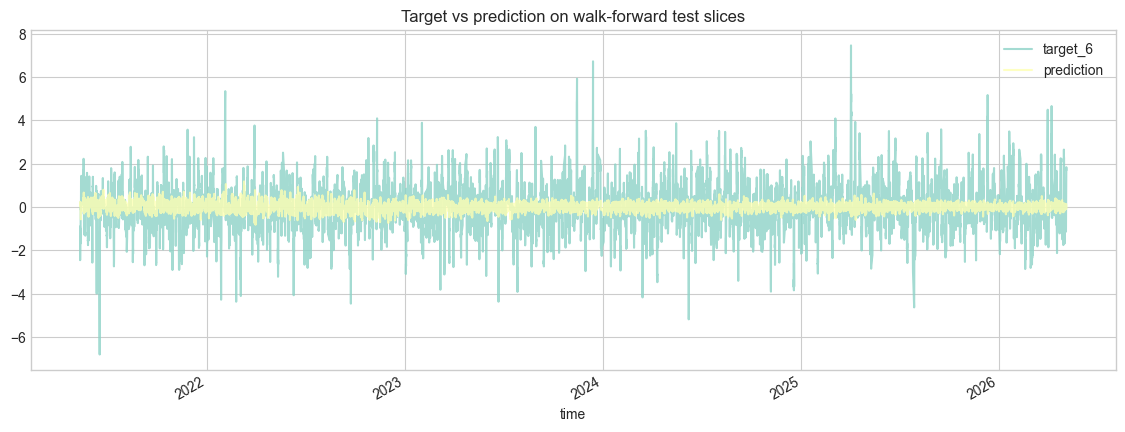

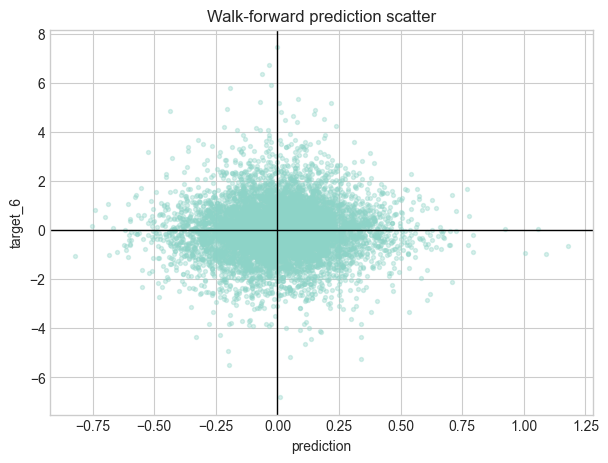

In [12]:
best_row = comparison.sort_values(["spearman_ic", "strategy_sharpe"], ascending=False).iloc[0]
BEST_GROUP = best_row["feature_group"]
BEST_HORIZON = int(best_row["horizon"])
BEST_MODEL_NAME = best_row["model"]
BEST_FEATURES = FEATURE_GROUPS[BEST_GROUP]

print("Recommended candidate from this research run:")
display(best_row.to_frame("value"))

best_pred = predictions[(BEST_GROUP, BEST_HORIZON, BEST_MODEL_NAME)]
best_pred[[f"target_{BEST_HORIZON}", "prediction"]].plot(figsize=(14, 5), alpha=0.8, title="Target vs prediction on walk-forward test slices")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(best_pred["prediction"], best_pred[f"target_{BEST_HORIZON}"], s=8, alpha=0.35)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.title("Walk-forward prediction scatter")
plt.xlabel("prediction")
plt.ylabel(f"target_{BEST_HORIZON}")
plt.show()

## 11. Final Fit for Interpretability

Fit the chosen shallow model on the latest available training sample for explanation. For production, refit only at scheduled retraining times and store model/version metadata.

In [13]:
def final_training_frame(data: pd.DataFrame, feature_cols: List[str], horizon: int) -> Tuple[pd.DataFrame, pd.Series]:
    target_col = f"target_{horizon}"
    frame = data[feature_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    return frame[feature_cols], frame[target_col]


X_final, y_final = final_training_frame(data, BEST_FEATURES, BEST_HORIZON)
final_model = clone(models[BEST_MODEL_NAME])
final_model.fit(X_final, y_final)

print(BEST_GROUP, BEST_HORIZON, BEST_MODEL_NAME, X_final.shape)

G1_pure_short_term_momentum 6 XGBoost (10854, 10)


## 12. Feature Importance

,native_importance
ewma_ret_20,0.117334
momentum_slope_10,0.111321
ewma_ret_10,0.108205
ret_2,0.100566
ret_1,0.097718
ret_5,0.095653
ret_3,0.094916
ewma_ret_5,0.094269
momentum_slope_20,0.090833
ret_10,0.089184


,permutation_importance
ewma_ret_20,0.028648
momentum_slope_10,0.022514
momentum_slope_20,0.021409
ret_10,0.015935
ret_5,0.015877
ret_2,0.013534
ewma_ret_10,0.011421
ret_1,0.010344
ewma_ret_5,0.010149
ret_3,0.009786


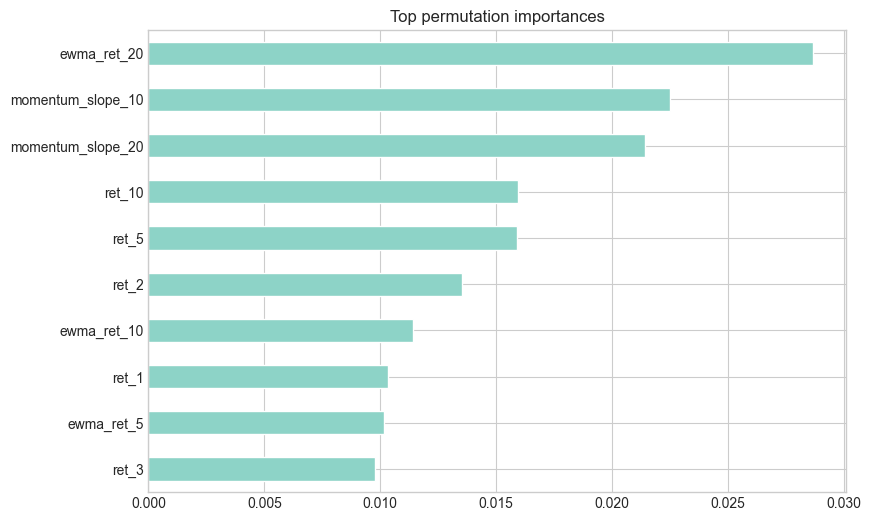

In [14]:
def model_feature_importance(model, feature_names: List[str]) -> pd.Series:
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    return pd.Series(dtype=float)


native_importance = model_feature_importance(final_model, BEST_FEATURES)
display(native_importance.head(15).to_frame("native_importance"))

perm = permutation_importance(
    final_model,
    X_final,
    y_final,
    scoring="neg_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
perm_importance = pd.Series(perm.importances_mean, index=BEST_FEATURES).sort_values(ascending=False)
display(perm_importance.head(15).to_frame("permutation_importance"))

perm_importance.head(15).sort_values().plot(kind="barh", figsize=(9, 6), title="Top permutation importances")
plt.show()

## 13. Shallow Decision Tree View

Even if the best model is Random Forest or XGBoost, a shallow decision tree trained on the same feature set is useful as an interpretable approximation.

|--- momentum_slope_20 <= 0.00089
|   |--- momentum_slope_10 <= 0.00019
|   |   |--- momentum_slope_10 <= 0.00018
|   |   |   |--- value: [-0.00683]
|   |   |--- momentum_slope_10 >  0.00018
|   |   |   |--- value: [-0.52333]
|   |--- momentum_slope_10 >  0.00019
|   |   |--- ewma_ret_20 <= 0.00040
|   |   |   |--- value: [0.10961]
|   |   |--- ewma_ret_20 >  0.00040
|   |   |   |--- value: [-0.05014]
|--- momentum_slope_20 >  0.00089
|   |--- momentum_slope_20 <= 0.00098
|   |   |--- value: [-0.37929]
|   |--- momentum_slope_20 >  0.00098
|   |   |--- ret_5 <= 0.00313
|   |   |   |--- value: [0.04683]
|   |   |--- ret_5 >  0.00313
|   |   |   |--- value: [-0.25989]



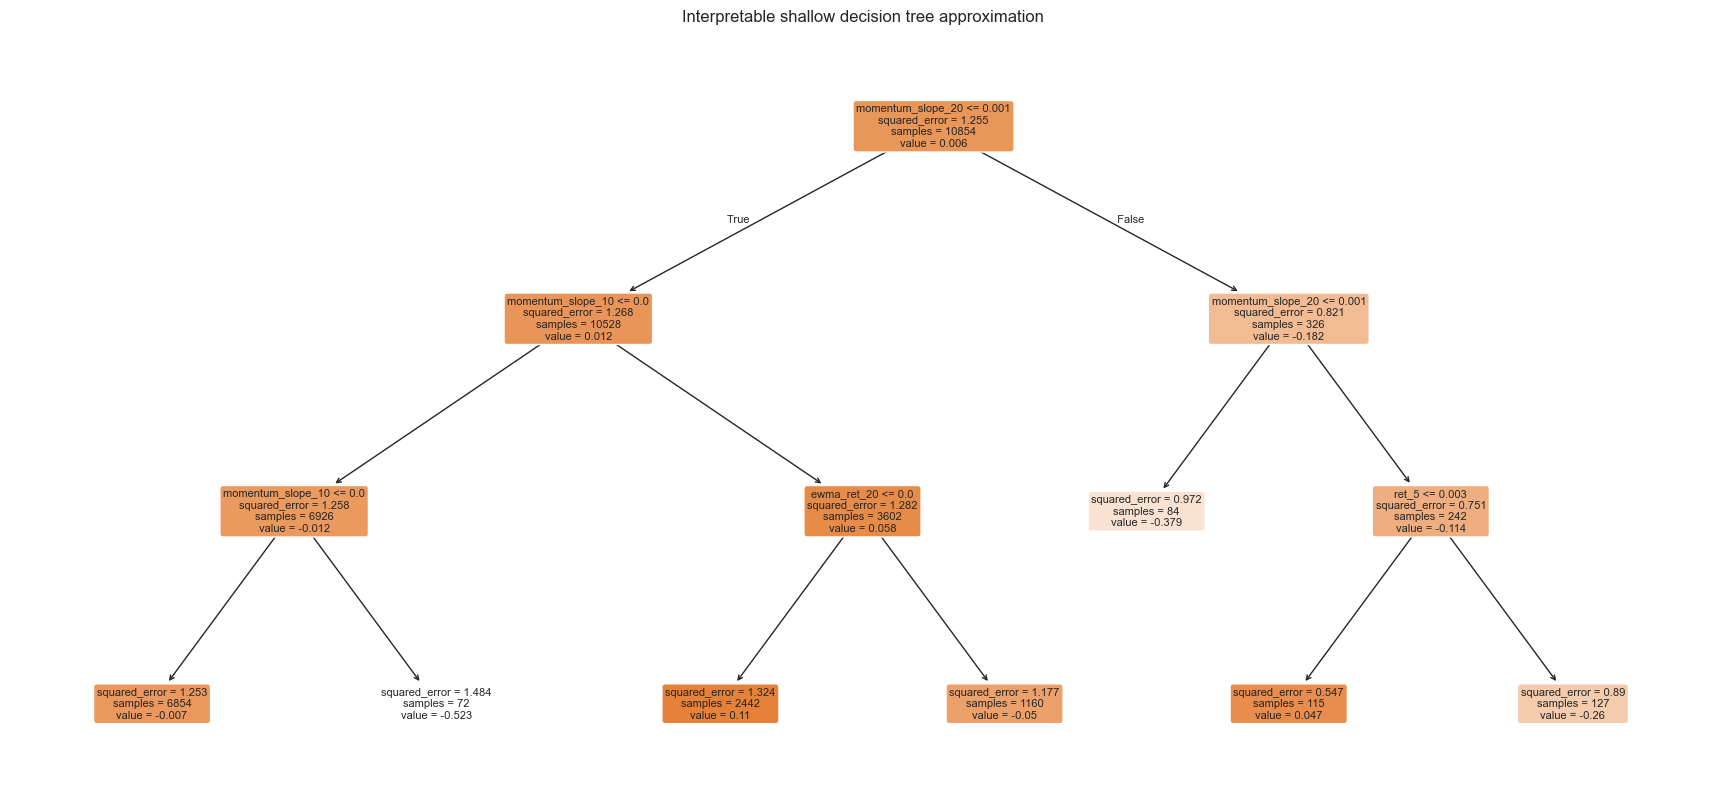

In [15]:
tree_probe = DecisionTreeRegressor(max_depth=MAX_TREE_DEPTH, min_samples_leaf=50, random_state=RANDOM_STATE)
tree_probe.fit(X_final, y_final)

print(export_text(tree_probe, feature_names=BEST_FEATURES, decimals=5, max_depth=MAX_TREE_DEPTH))

plt.figure(figsize=(22, 10))
plot_tree(
    tree_probe,
    feature_names=BEST_FEATURES,
    filled=True,
    rounded=True,
    max_depth=MAX_TREE_DEPTH,
    fontsize=8,
)
plt.title("Interpretable shallow decision tree approximation")
plt.show()

## 14. Partial Dependence for Top Features

In [ ]:
top_features = perm_importance.head(4).index.tolist()
if top_features:
    fig, ax = plt.subplots(figsize=(14, 8))
    PartialDependenceDisplay.from_estimator(
        final_model,
        X_final,
        features=top_features,
        kind="average",
        grid_resolution=30,
        ax=ax,
    )
    fig.suptitle("Partial dependence of top features", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No top features available for partial dependence.")

## 15. Coefficient-Like Linear Approximation

This does not replace the tree model. It provides a rough local/global summary of whether important features have positive or negative linear association with the target.

In [ ]:
ridge = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
ridge.fit(X_final, y_final)
ridge_model = ridge.named_steps["ridge"]

coef = pd.Series(ridge_model.coef_, index=BEST_FEATURES).sort_values(key=lambda s: s.abs(), ascending=False)
display(coef.head(20).to_frame("standardized_ridge_coef"))

coef.head(20).sort_values().plot(kind="barh", figsize=(9, 7), title="Coefficient-like linear approximation")
plt.show()

## 16. Practical Conclusion Template

After running the notebook, document the decision using concrete evidence:

- Best horizon: compare IC and Sharpe across 1, 3, and 6 bars.
- Best feature group: prefer the smallest group that performs comparably to the best group.
- Best model: prefer Decision Tree when performance is close; use Random Forest or shallow XGBoost only if the performance gain is stable.
- Stability checks: rerun with different train/test splits, rolling rather than expanding windows, higher transaction costs, and broker-specific spread assumptions.
- Production gating: freeze features, refit schedule, model versioning, execution delay, spread filter, max leverage, and kill-switch rules.

**Recommended default before seeing results:** start with `G4_regime_aware_interactions` and shallow `RandomForest` or `XGBoost`, then simplify to `G3` or a single shallow tree if performance is not materially worse. Keep `max_depth <= 4`.